In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [2]:
df = pd.read_csv("..\\data\\raw\\indian_roads_dataset.csv")

In [3]:
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [4]:
df.shape

(20000, 24)

**Check for nulls**

In [5]:
df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

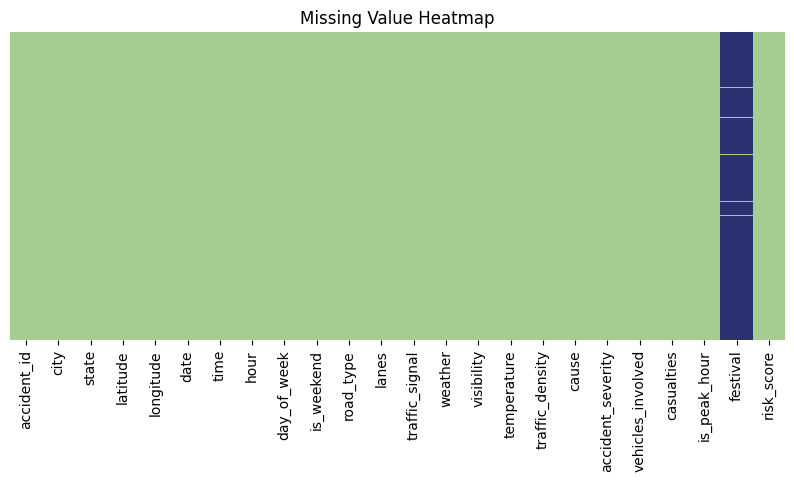

In [6]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='crest')
plt.title("Missing Value Heatmap")
plt.show()

In [7]:
invalid_coords = df[(df['latitude']==0) | (df['longitude']==0)]
print(f"Invalid (0,0) coordinates: {len(invalid_coords)}")

Invalid (0,0) coordinates: 0


#### Distribution Analysis (City and Severity)
**This helps you understand where your "Black Spots" will likely cluster.**

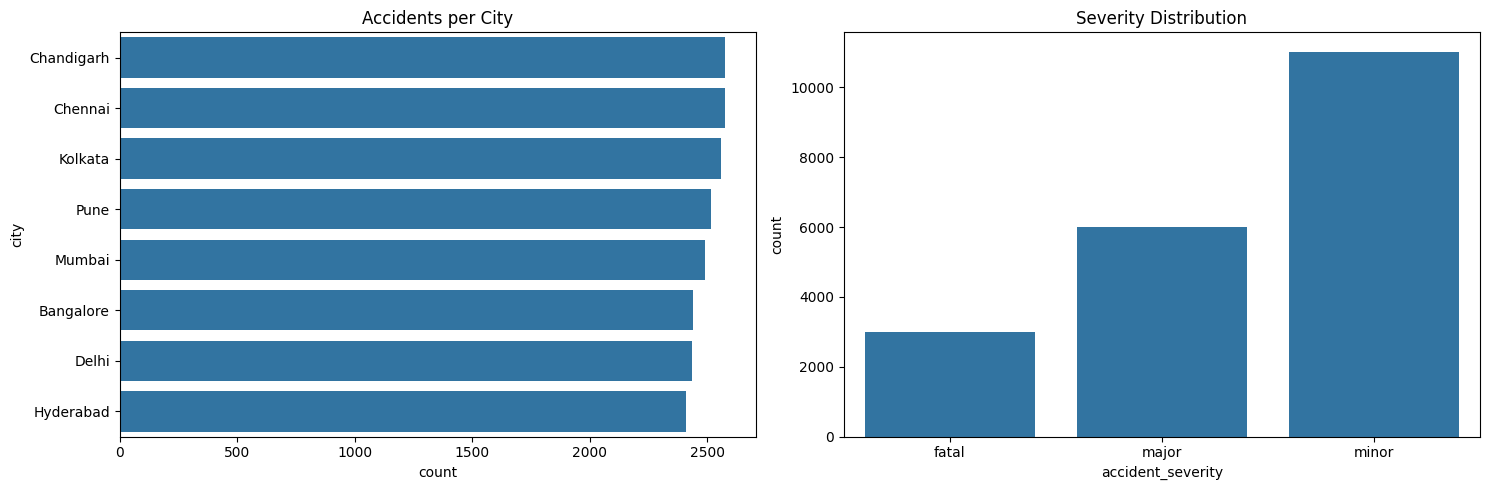

In [8]:
fig, ax = plt.subplots(1,2, figsize=(15,5))

#Accidents per city
sns.countplot(data=df, y='city', order=df['city'].value_counts().index, ax=ax[0])

ax[0].set_title('Accidents per City')

#Severity Distribution
sns.countplot(data=df, x='accident_severity', ax=ax[1])
ax[1].set_title('Severity Distribution')

plt.tight_layout()
plt.show()

#### Temporal Patterns (The When)
This is crucial for app's "Dynamic Alerts." If accidents peak at 8 PM, app could show a "Higher Risk" warning during that hour.

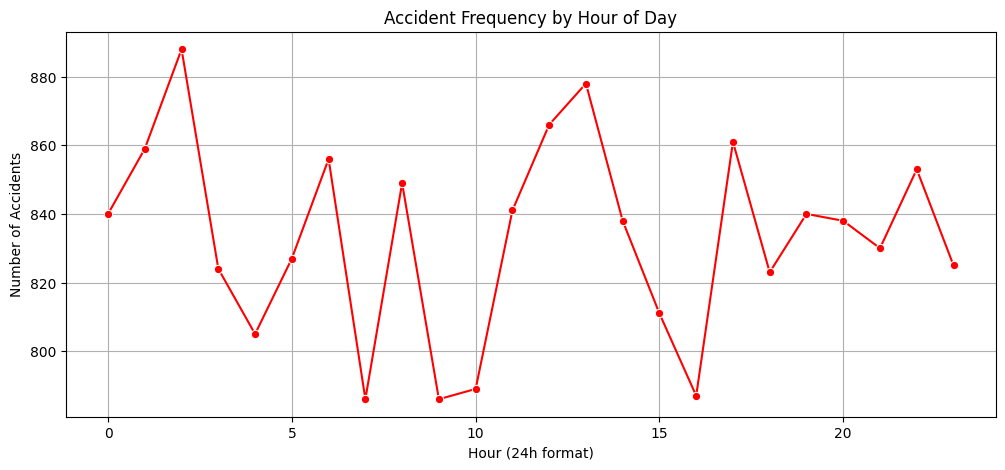

In [9]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df['hour'].value_counts().sort_index(), marker='o', color='red')
plt.title('Accident Frequency by Hour of Day')
plt.xlabel('Hour (24h format)')
plt.ylabel('Number of Accidents')
plt.grid(True)
plt.show()

##### Folium Map (Visualizing the "Where")
This creates an interactive map. Since plotting 10,000+ individual points will lag your browser, we use a HeatMap.

In [20]:
# create a base map centered on India
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# Prepare data for heatmap (list of [lat,lng])
heat_data = [[row['latitude'], row['longitude']] for index, row in df.iterrows()]

# Add heatmap layer
HeatMap(heat_data, radius=10).add_to(m)

# Save the map to view in browser or display in notebook
m.save('../../docs/raw_accident_map.html')
# display(m)